<a href="https://colab.research.google.com/github/EdwinEDW/Python/blob/main/DATOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Instalamos la herramienta para

*   !pip install unrar

##### Creamos una carpeta para los datos

* !mkdir carpeta_datos
* !unrar x prueba.rar carpeta_datos/

y descomprimimos



In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:

!pip install unrar

!mkdir carpeta_datos
!unrar x prueba.rar carpeta_datos/

mkdir: cannot create directory ‘carpeta_datos’: File exists

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from prueba.rar


Would you like to replace the existing file carpeta_datos/prueba/BAJA_CALIFORNIA/BCIMB005305.xlsx
 25906 bytes, modified on 2026-03-03 23:50
with a new one
 25906 bytes, modified on 2026-03-03 23:50

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit a

Extracting  carpeta_datos/prueba/BAJA_CALIFORNIA/BCIMB005305.xlsx          0%  OK 
Extracting  carpeta_datos/prueba/BAJA_CALIFORNIA/BCIMB107072.xlsx          0%  OK 
Extracting  carpeta_datos/prueba/BAJA_CALIFORNIA/BCIMB135658.xlsx          0%  OK 
Extracting  carpeta_datos/prueba/BAJA_CALIFORNIA/BCIMB167190.xlsx          0%  OK 
Extracting  carpeta_datos/prueba/BAJA_CALIFORNIA/BCIMB276920.xlsx          0%  OK 
Extracting  carpeta_datos/prueba/BAJA_CALIFORNIA/BCIMB284562.xlsx          0%  OK 
Extracting  carpeta_datos/prueba/B

* ###### 1. Buscamos todos los archivos Excel en Colab
* ###### 2.Unimos los archivos

* ###### 3. Mostrar la tabla

In [10]:
import pandas as pd
import glob
import os
archivos = glob.glob("**/*.xls*", recursive=True)
print(f"Se encontraron {len(archivos)} archivos.")
lista_df = []
for f in archivos:
    try:
        df_temp = pd.read_excel(f)
        df_temp['Origen'] = os.path.basename(f)
        lista_df.append(df_temp)
    except:
        continue
df_final = pd.concat(lista_df, ignore_index=True)
print("LA TABLA DE LA DATA PARA EL EXAMEN ES LA SIGUIENTE")
df_final

Se encontraron 1059 archivos.
LA TABLA DE LA DATA PARA EL EXAMEN ES LA SIGUIENTE


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,clave_kit_movil,clave_kit_cessa,clave_kit_hospital,clave_kit_hospital_basico_comunitario,clave_kit_hospital_ped,clave_kit_hospital_materno,clave_kit_hospital_psiquiatrico,clave_kit_uneme_pn,demanda,unidad
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSS,NOMBRE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279654,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
279655,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
279656,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
279657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


##### 1.-	Pega todas las bases de datos. Las unidades cometen errores y no siempre respetan los formatos, así que es posible que las hojas de Excel vengan en formatos con ligeras diferencias. Todo lo que hagas para leerlas debe ser mediante código. El resultado son las bases pegadas y el código que utilizaste para crearlo.

* Leer varios archivos con variaciones.


Aplicamos la limpieza directamente

Quita espacios al inicio/final, limpia saltos de línea internos y pasa a MAYÚSCULAS


1. Quita espacios al inicio/final, limpia saltos de línea internos y pasa a MAYÚSCULAS

2. Corrige el error de 'NAN' que genera el paso anterior para que vuelvan a ser vacíos reales

In [11]:
import pandas as pd
import numpy as np

for col in df_final.columns:
    if df_final[col].dtype == 'object':
        df_final[col] = df_final[col].astype(str).str.strip().str.replace(r'\s+', ' ',
        regex=True).str.upper()

        df_final[col] = df_final[col].replace(['NAN', 'NONE', 'NAT'], np.nan)
print("Limpieza  de mayusculas y  espacios")
df_final.head()

Limpieza  de mayusculas y  espacios


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,clave_kit_movil,clave_kit_cessa,clave_kit_hospital,clave_kit_hospital_basico_comunitario,clave_kit_hospital_ped,clave_kit_hospital_materno,clave_kit_hospital_psiquiatrico,clave_kit_uneme_pn,demanda,unidad
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSS,NOMBRE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Convertir a string y pasar a MAYÚSCULAS

In [12]:
import pandas as pd
import numpy as np
import re
def limpieza_total(texto):
    if pd.isna(texto):
        return texto

    s = str(texto).upper().strip()
    s = re.sub(r'[^A-Z0-9\s\._-]', '', s)
#        s = re.sub(r'\s+', ' ', s) ------------ESTE YA LO HICE EN EL PASO ANTERIOR / pero separado para hacerlo atomico
    return s
cols_criticas = ['entidad', 'clues', 'grupo', 'clave_cnis']
for col in cols_criticas:
    if col in df_final.columns:
        df_final[col] = df_final[col].apply(limpieza_total)
print("Caracteres string y pasar a MAYÚSCULAS")
df_final.head()

Caracteres string y pasar a MAYÚSCULAS


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,clave_kit_movil,clave_kit_cessa,clave_kit_hospital,clave_kit_hospital_basico_comunitario,clave_kit_hospital_ped,clave_kit_hospital_materno,clave_kit_hospital_psiquiatrico,clave_kit_uneme_pn,demanda,unidad
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSS,NOMBRE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


 ## Variable Categórica

In [13]:
def clasificar_insumo(clave):
    clave_str = str(clave).strip()
    if clave_str.startswith(('010', '020', '030', '040')):
        return 'MEDICAMENTOS'
    elif clave_str.startswith('060'):
        return 'MATERIAL DE CURACIÓN'
    else:
        return 'OTROS'
df_final['categoria_insumo'] = df_final['clave_cnis'].apply(clasificar_insumo)
print("MOSTRAMOS LOS DATOS DE LA NUEVA COLUMNA: categórica:")
print(df_final['categoria_insumo'].value_counts())
df_final.head()

MOSTRAMOS LOS DATOS DE LA NUEVA COLUMNA: categórica:
categoria_insumo
MEDICAMENTOS            145426
MATERIAL DE CURACIÓN    122342
OTROS                    11891
Name: count, dtype: int64


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,clave_kit_cessa,clave_kit_hospital,clave_kit_hospital_basico_comunitario,clave_kit_hospital_ped,clave_kit_hospital_materno,clave_kit_hospital_psiquiatrico,clave_kit_uneme_pn,demanda,unidad,categoria_insumo
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OTROS
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OTROS
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OTROS
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OTROS
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSS,NOMBRE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OTROS


#TAbla resumen por entidad federativa:
* tabla_resumen.columns (para dar formato)

In [14]:
import pandas as pd

tabla_resumen = df_final.groupby('entidad').agg({
    'clues': 'nunique',
    'clave_cnis': 'nunique',
    'cpm': 'sum'
}).reset_index()
tabla_resumen.columns = ['Entidad', 'No. CLUES (únicas)', 'No. Claves CNIS (únicas)', 'Total, de Demanda']
nacional = pd.DataFrame({
    'Entidad': ['NACIONAL'],
    'No. CLUES (únicas)': [df_final['clues'].nunique()],
    'No. Claves CNIS (únicas)': [df_final['clave_cnis'].nunique()],
    'Total, de Demanda': [df_final['cpm'].sum()]
})
tabla_final_examen = pd.concat([tabla_resumen, nacional], ignore_index=True)
tabla_final_examen

,Entidad,No. CLUES (únicas),No. Claves CNIS (únicas),"Total, de Demanda"
0,BAJA CALIFORNIA,16,1077,503044.0
1,BAJA CALIFORNIA SUR,8,1096,476574.0
2,CAMPECHE,15,470,394203.0
3,CHIAPAS,67,974,2055419.0
4,CIUDAD DE MEXICO,31,1046,1250772.0
5,COLIMA,14,274,339880.0
6,GUERRERO,104,984,2919882.0
7,HIDALGO,53,978,1676963.0
8,MEXICO,122,1227,4250491.0
9,MICHOACAN DE OCAMPO,46,941,1406219.0


## Gráfica de Pastel: insumos médicos demandados - insumo.

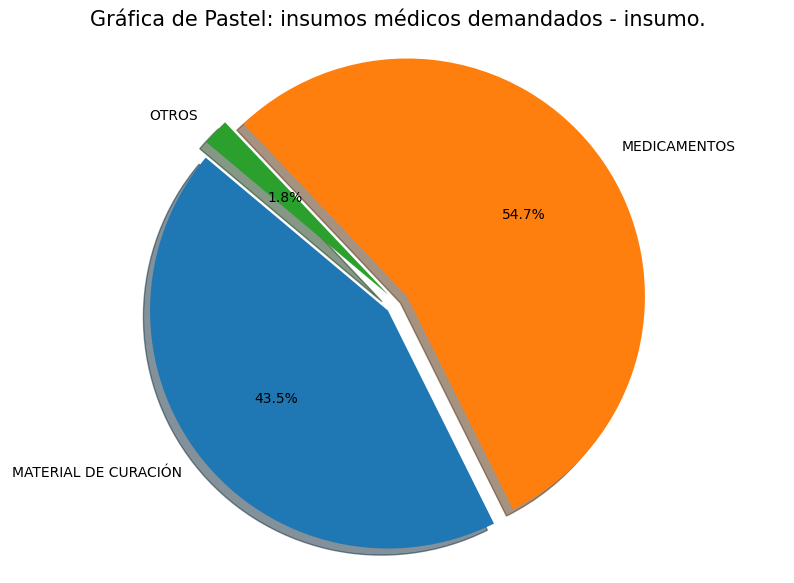

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
distribucion_nacional = df_final.groupby('categoria_insumo')['cpm'].sum()
plt.figure(figsize=(10, 7))
plt.pie(distribucion_nacional,
        labels = distribucion_nacional.index,
        autopct='%1.1f%%',
        startangle=140,
        explode=(0.05, 0.05, 0.05),
        shadow=True)
plt.title('Gráfica de Pastel: insumos médicos demandados - insumo.', fontsize=15)
plt.axis('equal')
plt.show()

#Gastos

In [21]:
import pandas as pd
tabla_gasto = df_final.groupby('categoria_insumo')['cpm'].sum().reset_index()
tabla_gasto.columns = ['Categoría de Insumo', 'Gasto Total (Demanda)']
tabla_gasto['Gasto Total (Demanda)'] = tabla_gasto['Gasto Total (Demanda)'].map('{:,.0f}'.format)
total_general = df_final['cpm'].sum()
fila_total = pd.DataFrame({
    'Categoría de Insumo': [' TOTAL GENERAL'],
    'Gasto Total (Demanda)': [  '{:,.0f}'.format(total_general)  ]
})
tabla_gasto_final = pd.concat([tabla_gasto, fila_total], ignore_index=True)
print("****** TABLA DE GASTO POR CATEGORÍA")
tabla_gasto_final

****** TABLA DE GASTO POR CATEGORÍA


,Categoría de Insumo,Gasto Total (Demanda)
0,MATERIAL DE CURACIÓN,"14,360,749"
1,MEDICAMENTOS,"18,078,505"
2,OTROS,"602,723"
3,TOTAL GENERAL,"33,041,977"
